In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score
from imblearn.over_sampling import SMOTE

### Koshish yeh hogi meri is bar k encoding kr data ko eik bar export kr k model save karlon jaisa ap ny class main bataya tha pickle ka use kr k

In [7]:
df = pd.read_csv('fraud_data_cleanned.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           5000 non-null   object 
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   country               5000 non-null   object 
 4   avg_order_value       5000 non-null   float64
 5   total_orders          5000 non-null   int64  
 6   last_purchase         5000 non-null   int64  
 7   is_fraudulent         5000 non-null   int64  
 8   preferred_category    5000 non-null   object 
 9   email_open_rate       5000 non-null   float64
 10  loyalty_score         5000 non-null   int64  
 11  churn_risk            5000 non-null   float64
 12  customer_tenure_days  5000 non-null   int64  
dtypes: float64(3), int64(6), object(4)
memory usage: 507.9+ KB


,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_tenure_days
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.60,50,0.20,800
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.30,37,0.34,907
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,50.95,65,0.05,850
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.90,93,0.19,2228
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.30,79,0.15,492


### Plot kr k relationShip check karlete hain banay ga fraudulent k sath

/tmp/ipykernel_50339/3035723765.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_fraudulent', ax=axes[0, 0], palette='YlGnBu')
/tmp/ipykernel_50339/3035723765.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraudulent', y='avg_order_value', ax=axes[0, 1], palette='YlGnBu')


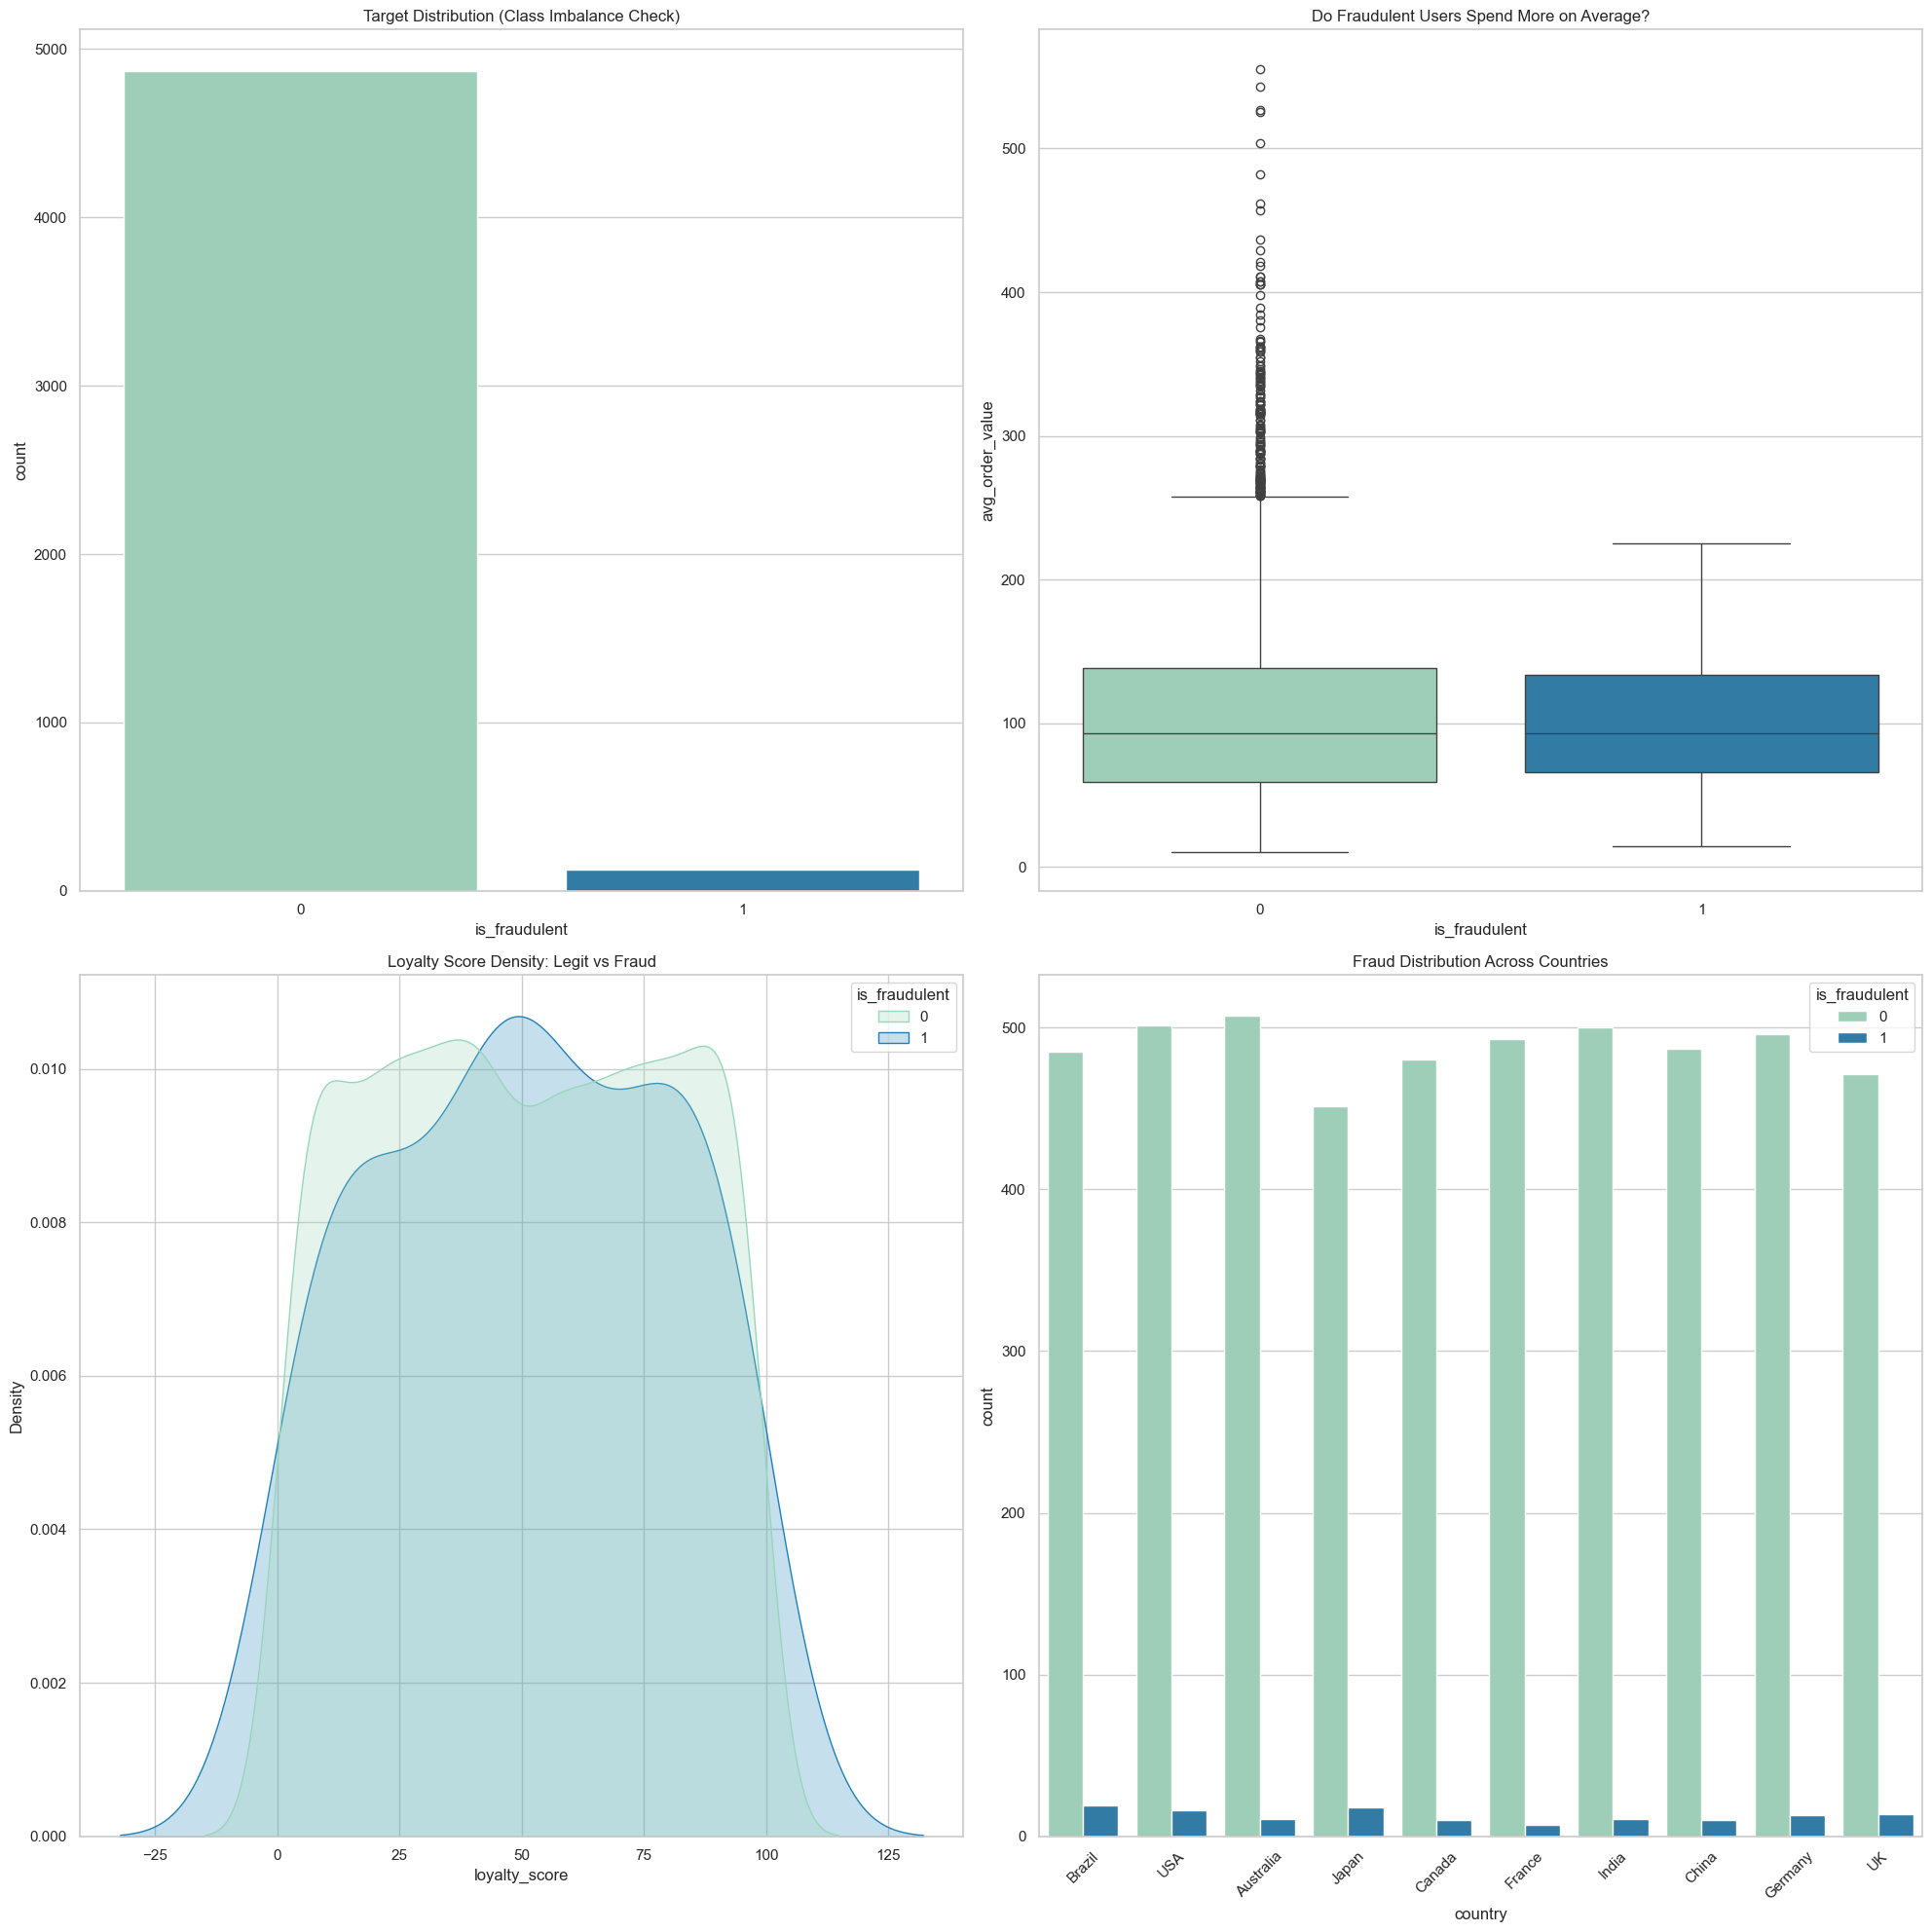

In [24]:
# sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# 1. Target Imbalance
sns.countplot(data=df, x='is_fraudulent', ax=axes[0, 0], palette='YlGnBu')
axes[0, 0].set_title('Target Distribution (Class Imbalance Check)')

# 2. Spend Behavior vs Fraud
sns.boxplot(data=df, x='is_fraudulent', y='avg_order_value', ax=axes[0, 1], palette='YlGnBu')
axes[0, 1].set_title('Do Fraudulent Users Spend More on Average?')

# 3. Customer Engagement vs Fraud
sns.kdeplot(data=df, x='loyalty_score', hue='is_fraudulent', fill=True, common_norm=False, ax=axes[1, 0], palette='YlGnBu')
axes[1, 0].set_title('Loyalty Score Density: Legit vs Fraud')

# 4. Regional Fraud Vulnerability
sns.countplot(data=df, x='country', hue='is_fraudulent', ax=axes[1, 1], palette='YlGnBu')
axes[1, 1].set_title('Fraud Distribution Across Countries')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [26]:
df.head(4)

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_tenure_days
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.60,50,0.20,800
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.30,37,0.34,907
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,50.95,65,0.05,850
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.90,93,0.19,2228


## Feature Engineering

In [27]:
df['total_spend'] = df['avg_order_value'] * df['total_orders']

In [28]:
df['order_velocity'] = df['total_orders'] /(df['loyalty_score'] + 1)

In [30]:
df['order_velociy'] = df['total_orders'] / (df['last_purchase'] + 1)

In [31]:
df.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_tenure_days,total_spend,order_velocity,order_velociy
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.60,50,0.20,800,808.64,0.156863,0.045198
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.30,37,0.34,907,903.90,0.263158,0.112360
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,50.95,65,0.05,850,499.68,0.090909,0.029412
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.90,93,0.19,2228,989.10,0.095745,0.025937
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.30,79,0.15,492,4310.08,0.200000,0.046647


In [83]:
df.to_csv('process_data.csv' ,index =False)